# Systemic Risk Spillovers Between European Banks and NBFIs

**Master's thesis research project | Lund University**

This notebook studies directional tail-risk spillovers between listed European banks and non-bank financial intermediaries (NBFIs) from 2015 to 2025. It combines a Python data pipeline and panel-regression workflow with R-based DCC-GJR-GARCH modelling through `rpy2`.

> **Data note:** The raw Bloomberg data cannot be shared because of licensing restrictions. The notebook is retained as a fully rendered record of the workflow, outputs and results.


## Analysis notebook


## Python packages


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from scipy.stats import norm
from scipy.stats import t
from arch import arch_model
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
from statsmodels.tsa.stattools import grangercausalitytests
from linearmodels.panel import PanelOLS
from linearmodels.panel import PooledOLS
import matplotlib.dates as mdates

## Data preparation and cleaning


### Load and clean the data

In [2]:
#Clean the data
def clean_bbg(df_raw):
    clean_df = pd.DataFrame()
    for i in range(0, len(df_raw.columns), 2):
        temp = df_raw.iloc[:, [i, i+1]].copy()
        temp.columns = ['Date', temp.columns[1]]
        temp['Date'] = pd.to_datetime(temp['Date'])
        temp = temp.dropna().set_index('Date')
        if clean_df.empty:
            clean_df = temp
        else:
            clean_df = clean_df.join(temp, how='outer')
    return clean_df
    
#Load the data
df_prices_raw = pd.read_excel('Data.xlsx', 'Daily prices adjusted')
df_index_raw = pd.read_excel('Data.xlsx', 'Index')
df_macro_raw = pd.read_excel('Data.xlsx', 'Macro')
df_sectors = pd.read_excel('Data.xlsx', sheet_name='Sector')

df_prices = clean_bbg(df_prices_raw)
df_index = clean_bbg(df_index_raw)
df_macro = clean_bbg(df_macro_raw)

### Calculate log daily returns


In [3]:
# Formula: ln(Price today / Price yesterday)
df_returns_stocks = np.log(df_prices / df_prices.shift(1))
df_returns_index = np.log(df_index / df_index.shift(1))

# The data we look at ( can maybe get rid off)
df_returns_stocks = df_returns_stocks.loc['2014-01-01':'2025-12-31']
df_returns_index = df_returns_index.loc['2014-01-01':'2025-12-31']

# Remove non-trading days
df_returns_stocks.dropna(how='all', inplace=True)
df_returns_index.dropna(how='all', inplace=True)

### Construct the NBFI index


In [4]:
# Create NBFI index with market cap of SXFP and SXIP by 2014-12-30
# SXFP 0.154 M
# SXIP 0.509 M
total_cap = 0.154 + 0.509
w_sxfp = 0.154 / total_cap  # Financial service (~23.2%)
w_sxip = 0.509 / total_cap  # Insurance (~76.8%)

# Create the Index
nbfi_weighted_ret = (df_returns_index['SXFP Index'] * w_sxfp) + (df_returns_index['SXIP Index'] * w_sxip)
df_returns_index['NBFI_Weighted'] = nbfi_weighted_ret

### Identify banks and NBFIs


In [5]:
bank_tickers = df_sectors[df_sectors['Type'] == 'Bank']['Ticker'].tolist()
NBFI_tickers = df_sectors[df_sectors['Type'].isin(['Insurance', 'Financial Services'])]['Ticker'].tolist()

### Create state variables

In [6]:
df_state = pd.DataFrame(index=df_macro.index)

# Volatility index
df_state['V2X_Level'] = df_macro['V2X Index'] 

# Calculate yield curve slope
df_state['Term_Spread'] = df_macro['GTDEM10Y Govt'] - df_macro['EUR003M Index'] 

# Credit spread (Itrax CDS) (Credit risk)
df_state['Credit_Spread'] = df_macro['ITRX EUR  CDSI GEN 5Y Index'] 

# # Market return
df_state['Market_Return'] = df_returns_index['SXXP Index'] 

# Create OIS index for Liquidity_Spread use 2 index as it changed in 2022
# Before 2022-01-01: Use EONIA -0.085 (Source ECB) (EUSWE3 Curncy)
# From 2022-01-01: Use €STR (EESWE3)
df_macro['OIS'] = np.where(
    df_macro.index < pd.Timestamp('2022-01-01'),
    df_macro['EUSWE3 Curncy'] - 0.085,
    df_macro['EESWE3 Curncy']
)

# Liquidity Spread (EURIBOR 3M - OIS)
df_state['Liquidity_Spread'] = (df_macro['EUR003M Index'] - df_macro['OIS'])


### Create the final analytical dataset


In [7]:
# Create the final file with the adjused date
df_final = pd.concat([df_returns_stocks, df_returns_index, df_state], axis=1)

# Drop everything outside after the observation period we keep 2014 as a "burn_in period"
df_final = df_final.loc[:'2025-12-31'].dropna(subset=['SXXP Index']) #not how=all because index might report on nontrading days

## Descriptive statistics


In [8]:
# Create empty list
stats_list = []

# Define variables that is already in %
variable_procent =['V2X_Level', 'Term_Spread', 'Credit_Spread', 'Liquidity_Spread']

# Loop df_final 
for col in df_final.columns:
    series = df_final[col].dropna()
    
   # Use 1 as multiplier for macro, 100 for log-returns
    multiplier = 1 if col in variable_procent else 100
    
    mean_val = series.mean() * multiplier
    std_val  = series.std() * multiplier
    min_val  = series.min() * multiplier
    max_val  = series.max() * multiplier
    skew_val = series.skew() # Skewness
    kurt_val = series.kurtosis() # Kurtosis (tails)
    _,jb_pval = stats.jarque_bera(series) # Test for normality and _, to fix table formating
    adf_res = adfuller(series) # Augmented Dickey-Fuller (test for normality)
    adf_pval = adf_res[1] # Get the p_value of the adf
    
    # Create the table
    stats_list.append({
        'Variable': col,
        'Mean (%)': mean_val,
        'Std. Dev. (%)': std_val,
        'Min (%)': min_val,
        'Max (%)': max_val,
        'Skewness': skew_val,
        'Kurtosis': kurt_val,
        'JB (p-val)': jb_pval,
        'ADF (p-val)': adf_pval
    })

# Formatting
stats_df = pd.DataFrame(stats_list)

stats_df.set_index('Variable', inplace=True)

stats_df = stats_df.round(4)

print(stats_df)
stats_df.to_excel("Descriptive_Statistics_Final.xlsx")

                  Mean (%)  Std. Dev. (%)  Min (%)   Max (%)  Skewness  \
Variable                                                                 
HSBA LN Equity      0.0399         1.5813  -9.9663   10.6045   -0.3300   
SAN SQ Equity       0.0348         2.0894 -22.1735   17.5850   -0.6625   
LLOY LN Equity      0.0197         2.0259 -29.2764   13.4251   -1.0664   
BNP FP Equity       0.0341         1.9381 -19.1166   16.5352   -0.6414   
NWG LN Equity       0.0355         2.2223 -25.6061   12.7069   -0.8441   
...                    ...            ...      ...       ...       ...   
V2X_Level          20.0536         6.8782  10.6783   85.6206    2.6221   
Term_Spread         0.2412         0.7237  -2.0320    1.9940   -0.9918   
Credit_Spread      65.8525        16.3699  41.2770  138.5490    1.3565   
Market_Return       0.0194         1.0028 -12.1915    8.0704   -1.0859   
Liquidity_Spread    0.1083         0.5018  -2.2110    1.6498   -0.4347   

                  Kurtosis  JB (p-val

### First-differencing of non-stationary variables

In [9]:
# Term_Spread, Liquidity_Spread and Credit_Spread is non stationary at the 1% level, we take first diffrence
df_state['Term_Spread'] = (df_macro['GTDEM10Y Govt'] - df_macro['EUR003M Index']).diff()
df_state['Credit_Spread'] = df_macro['ITRX EUR  CDSI GEN 5Y Index'].diff()
df_state['Liquidity_Spread'] = (df_macro['EUR003M Index'] - df_macro['OIS']).diff()

# Create the final file with the adjused date
df_final = pd.concat([df_returns_stocks, df_returns_index, df_state], axis=1)

# Drop everything outside after the observation period we keep 2014 as a "burn_in period"
df_final = df_final.loc[:'2025-12-31'].dropna(how='all')

### Updated descriptive statistics


In [10]:
# Create empty list
stats_list = []

# Define variables that is already in %
variable_procent =['V2X_Level', 'Term_Spread', 'Credit_Spread', 'Liquidity_Spread']

# Loop df_final 
for col in df_final.columns:
    series = df_final[col].dropna()
    
   # Use 1 as multiplier for macro, 100 for log-returns
    multiplier = 1 if col in variable_procent else 100
    
    mean_val = series.mean() * multiplier
    std_val  = series.std() * multiplier
    min_val  = series.min() * multiplier
    max_val  = series.max() * multiplier
    skew_val = series.skew() # Skewness
    kurt_val = series.kurtosis() # Kurtosis (tails)
    _,jb_pval = stats.jarque_bera(series) # Test for normality and _, to fix table formating
    adf_res = adfuller(series) # Augmented Dickey-Fuller (test for stationarity)
    adf_pval = adf_res[1] # Get the p_value of the adf
    
    # Create the table
    stats_list.append({
        'Variable': col,
        'Mean (%)': mean_val,
        'Std. Dev. (%)': std_val,
        'Min (%)': min_val,
        'Max (%)': max_val,
        'Skewness': skew_val,
        'Kurtosis': kurt_val,
        'JB (p-val)': jb_pval,
        'ADF (p-val)': adf_pval
    })

# Formatting
stats_df = pd.DataFrame(stats_list)

stats_df.set_index('Variable', inplace=True)

stats_df = stats_df.round(4)

print(stats_df)
# stats_df.to_excel("Descriptive_Statistics_Final.xlsx")

                  Mean (%)  Std. Dev. (%)  Min (%)  Max (%)  Skewness  \
Variable                                                                
HSBA LN Equity      0.0399         1.5813  -9.9663  10.6045   -0.3300   
SAN SQ Equity       0.0348         2.0894 -22.1735  17.5850   -0.6625   
LLOY LN Equity      0.0197         2.0259 -29.2764  13.4251   -1.0664   
BNP FP Equity       0.0341         1.9381 -19.1166  16.5352   -0.6414   
NWG LN Equity       0.0355         2.2223 -25.6061  12.7069   -0.8441   
...                    ...            ...      ...      ...       ...   
V2X_Level          20.0532         6.8771  10.6783  85.6206    2.6227   
Term_Spread        -0.0003         0.0460  -0.3520   0.3650   -0.1073   
Credit_Spread      -0.0104         2.3063 -21.3150  25.2380    0.7783   
Market_Return       0.0194         1.0028 -12.1915   8.0704   -1.0859   
Liquidity_Spread    0.0001         0.0389  -0.3930   0.3253    0.5536   

                  Kurtosis  JB (p-val)  ADF (p-val

In [11]:
# Calculate averages for descriptive statistics table in text.

# Take the mean for the Banks
bank_stats_mean = stats_df.loc[stats_df.index.isin(bank_tickers)].mean()

# Take the mean for the NBFIs
nbfi_stats_mean = stats_df.loc[stats_df.index.isin(NBFI_tickers)].mean()

# Create a dataframe
panel_a_df = pd.DataFrame({
    f'Banks (Average, N={len(bank_tickers)})': bank_stats_mean,
    f'NBFIs (Average, N={len(NBFI_tickers)})': nbfi_stats_mean
}).T # Transpose

# Pick out the important columns
columns_to_keep = ['Mean (%)', 'Std. Dev. (%)', 'Skewness', 'Kurtosis']
panel_a_clean = panel_a_df[columns_to_keep].round(4)

print("--- Panel A: Firm-Level Aggregates ---")
print(panel_a_clean)

--- Panel A: Firm-Level Aggregates ---
                       Mean (%)  Std. Dev. (%)  Skewness  Kurtosis
Banks (Average, N=27)    0.0300         2.0639   -0.9731   20.6627
NBFIs (Average, N=48)    0.0364         1.7749   -0.7150   25.0143


## DCC-GARCH modelling


### Select the mean equation


In [12]:
# get rid of the warnings for ARMA process that don't fit the data
warnings.simplefilter('ignore', UserWarning)

In [13]:
# Index to test
target_indexes = ['SX7P Index', 'NBFI_Weighted']

# Models to compare
candidate_models = {
    "ARMA(0,0)": (0, 0, 0), 
    "AR(1)": (1, 0, 0),
    "AR(2)": (2, 0, 0),
    "MA(1)": (0, 0, 1),
    "MA(2)": (0, 0, 2),
    "ARMA(1,1)": (1, 0, 1),
    "ARMA(2,2)": (2, 0, 2)
}
# Test different ARMA processes for SX7P and NBFI_Weighted for AIC and BIC
for idx_name in target_indexes:
    print(f"\n--- Analysis for: {idx_name} ---")
    results_list = []
    series = df_returns_index[idx_name].dropna()

    for name, order in candidate_models.items():
        # Fit the model
        model_fit = ARIMA(series, order=order, trend='c').fit()
        
        results_list.append({
            'Model': name,
            'AIC': model_fit.aic,
            'BIC': model_fit.bic
        })

    # Create table and sort by BIC (lowest/most negative at the top)
    comparison_df = pd.DataFrame(results_list).sort_values('BIC')
    print(comparison_df.to_string(index=False))


--- Analysis for: SX7P Index ---
    Model           AIC           BIC
ARMA(0,0) -16871.756733 -16859.692013
    AR(1) -16871.404506 -16853.307425
    MA(1) -16871.296454 -16853.199374
    MA(2) -16873.109130 -16848.979690
    AR(2) -16873.058553 -16848.929113
ARMA(1,1) -16870.839228 -16846.709787
ARMA(2,2) -16869.135807 -16832.941646

--- Analysis for: NBFI_Weighted ---
    Model           AIC           BIC
ARMA(0,0) -18379.684061 -18367.619341
    AR(1) -18385.410855 -18367.313774
    MA(1) -18384.722846 -18366.625766
    AR(2) -18390.237546 -18366.108105
    MA(2) -18390.234345 -18366.104904
ARMA(1,1) -18387.226379 -18363.096938
ARMA(2,2) -18386.105640 -18349.911479


BIC suggests ARMA(0,0).


### Test for asymmetry


R is used for the DCC-GARCH estimation because of its specialised GARCH packages.


In [14]:
%load_ext rpy2.ipython

In [15]:
%%R -i df_final -o index_signbias_df

library(rugarch)

# The indexes we will check
index_assets <- c("SX7P Index", "NBFI_Weighted")

# Define the base model: ARMA(0,0) och GARCH(1,1)
uspec_base <- ugarchspec(variance.model = list(model = "sGARCH", garchOrder = c(1, 1)),
                         mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
                         distribution.model = "std")

# Create frame to save data in (UPPDATERAD FÖR ALLA FYRA P-VÄRDEN)
signbias_results <- data.frame(Index = character(), 
                               Sign_Bias_Pval = numeric(),
                               Neg_Size_Bias_Pval = numeric(),
                               Pos_Size_Bias_Pval = numeric(),
                               Joint_Effect_Pval = numeric(), 
                               stringsAsFactors = FALSE)

# Test the indexes
for (ticker in index_assets) {
  
    # Extract the time series
    ret_series <- na.omit(df_final[, ticker]) * 100
  
    # Fit the base model
    fit <- ugarchfit(spec = uspec_base, data = ret_series, solver = "hybrid")
    
    # Run the Engle-NG test
    sb_test <- signbias(fit)
    
    # Extract ALL p-values from the test:
    # prob[1] = Sign Bias
    # prob[2] = Negative Size Bias (Den kritiska för hävstångseffekten!)
    # prob[3] = Positive Size Bias
    # prob[4] = Joint Effect (Bevisar total asymmetri)
    
    p_sign  <- sb_test$prob[1]
    p_neg   <- sb_test$prob[2]
    p_pos   <- sb_test$prob[3]
    p_joint <- sb_test$prob[4] 
    
    # Save in result table
    signbias_results <- rbind(signbias_results, 
                              data.frame(Index = ticker, 
                                         Sign_Bias_Pval = p_sign,
                                         Neg_Size_Bias_Pval = p_neg,
                                         Pos_Size_Bias_Pval = p_pos,
                                         Joint_Effect_Pval = p_joint))
}

# Send to python 'index_signbias_df'
index_signbias_df <- signbias_results

Loading required package: parallel


In [16]:
display(index_signbias_df)

,Index,Sign_Bias_Pval,Neg_Size_Bias_Pval,Pos_Size_Bias_Pval,Joint_Effect_Pval
1,SX7P Index,0.451202,0.177770,0.342158,0.025401
2,NBFI_Weighted,0.346934,0.019764,0.190860,0.000258


GJR-GARCH is used because the index exhibits asymmetric volatility.


### Ljung-Box test of standardised residuals


In [17]:
%%R -i df_final

library(rugarch)

# The indexes to test
target_indexes <- c("SX7P Index", "NBFI_Weighted")

# Define the chosen model: ARMA(0,0) + GJR-GARCH(1,1) with Student-t distribution
spec <- ugarchspec(variance.model = list(model = "gjrGARCH", garchOrder = c(1, 1)),
                   mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
                   distribution.model = "std")

for (idx_name in target_indexes) {
    
    # Extract the time series and scale by 100
    ret_series <- na.omit(df_final[, idx_name]) * 100
    
    # Fit the model for the specific index
    fit <- ugarchfit(spec = spec, data = ret_series, solver = "hybrid")
    
    # Extract the standardized residuals (cleared from volatility clustering)
    std_res <- residuals(fit, standardize = TRUE)
    
    # Run the Ljung-Box test
    lb_test <- Box.test(std_res, lag = 10, type = "Ljung-Box")
    
    print(paste("Ljung-Box test on standardized residuals for:", idx_name, ""))
    print(lb_test)
}

[1] "Ljung-Box test on standardized residuals for: SX7P Index "

	Box-Ljung test

data:  std_res
X-squared = 6.7878, df = 10, p-value = 0.7453

[1] "Ljung-Box test on standardized residuals for: NBFI_Weighted "

	Box-Ljung test

data:  std_res
X-squared = 14.403, df = 10, p-value = 0.1554



The model passes the Ljung-Box test.


### DCC-GARCH estimation loop


In [18]:
%%R -i df_final -i bank_tickers -i NBFI_tickers -o dcc_results_df

# Load required packages for GARCH and DCC modeling
library(rugarch)
library(rmgarch)

# Initialize an empty list to store the results for each bank
results_list <- list()

# Specify the model 

# Specify the univariate GARCH(1,1) model with a Student-t distribution.
# We include a constant mean (include.mean = TRUE) which
uspec <- ugarchspec(variance.model = list(model = "gjrGARCH", garchOrder = c(1, 1)),
                    mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
                    distribution.model = "std") 

# Replicate the univariate specification for the bivariate setup (Bank + System)
multispec <- multispec(replicate(2, uspec))

# Specify the DCC model with a multivariate Student-t distribution (mvt)
# This captures the fat tails and dynamic correlations typical in financial crises.
dcc_spec <- dccspec(uspec = multispec, dccOrder = c(1, 1), distribution = "mvt")

# Index vs Index 
# -----------------------------------------------------------------------------------------------------------------------------

# Extract the pair of returns for the indices, drop NAs, and scale by 100 for GARCH convergence
# Note: We only run the DCC-GARCH model in one direction since the dynamic correlation is symmetric.
# The reversed spillover effects are calculated mathematically later in the Python script.
data_pair_idx <- na.omit(df_final[, c("SX7P Index", "NBFI_Weighted")]) * 100

# Fit the DCC-GARCH model
fit_result_idx <- dccfit(dcc_spec, data = data_pair_idx, solver = "solnp", fit.control = list(eval.se = FALSE))
all_coefs_idx <- coef(fit_result_idx)                    

# Extract dynamic conditional correlation, volatilities and mean
results_list[["Index_to_Index"]] <- data.frame(
  Date = as.character(rownames(data_pair_idx)),
  Entity = "SX7P Index",
  Index_Name = "NBFI_Weighted",
  Direction = "BankIndex_to_NBFIIndex", # To be able to filter later
  Correlation = as.numeric(rcor(fit_result_idx)[1, 2, ]),
  Vol_Entity = as.numeric(sigma(fit_result_idx)[, 1]), # Bank Index
  Vol_Index = as.numeric(sigma(fit_result_idx)[, 2]),  # NBFI Index
  Mean_Entity = as.numeric(fitted(fit_result_idx)[, 1]),
  Mean_Index = as.numeric(fitted(fit_result_idx)[, 2]),
  Shape_Entity = as.numeric(all_coefs_idx["[SX7P Index].shape"]),
  Shape_Index = as.numeric(all_coefs_idx["[NBFI_Weighted].shape"])
)

# Banks vs NBFI-Index
# -----------------------------------------------------------------------------------------------------------------------------

# Loop through each bank to estimate the bivariate model against the NBFI Index
for(ticker in bank_tickers) {
    
  # Extract the pair of returns (Bank and NBFI-Index), drop NAs, and scale by 100 
  # to help the optimization algorithm converge
  data_pair <- na.omit(df_final[, c(ticker, "NBFI_Weighted")]) * 100
  
  # Fit the DCC-GARCH model. 
  # eval.se = FALSE speeds up estimation by skipping standard error calculations.
  fit_result <- dccfit(dcc_spec, data = data_pair, solver = "solnp", fit.control = list(eval.se = FALSE))

  all_coefs <- coef(fit_result)                    

  # Extract dynamic conditional correlation (rho), volatilities (sigma) and mean (mu)
  # as.numeric() is critical here to strip away internal R names, 
  # ensuring clean data binding in the final step.
  results_list[[paste0(ticker, "_to_NBFI")]] <- data.frame(
    Date = as.character(rownames(data_pair)),
    Entity = ticker,
    Index_Name = "NBFI_Weighted",
    Direction = "Bank_to_NBFI", # To be able to filter later
    Correlation = as.numeric(rcor(fit_result)[1, 2, ]),
    Vol_Entity = as.numeric(sigma(fit_result)[, 1]), # Bank
    Vol_Index = as.numeric(sigma(fit_result)[, 2]),  # NBFI Index
    Mean_Entity = as.numeric(fitted(fit_result)[, 1]),
    Mean_Index = as.numeric(fitted(fit_result)[, 2]),
    Shape_Entity = as.numeric(all_coefs[paste0("[", ticker, "].shape")]),
    Shape_Index = as.numeric(all_coefs["[NBFI_Weighted].shape"])
  )
}

# NBFI vs SX7P (Bank index)
# -----------------------------------------------------------------------------------------------------------------------------

# Loop through each NBFI to estimate the bivariate model against the SX7P Index 
for(ticker in NBFI_tickers) {
 
  data_pair <- na.omit(df_final[, c(ticker, "SX7P Index")]) * 100
  
  fit_result <- dccfit(dcc_spec, data = data_pair, solver = "solnp", fit.control = list(eval.se = FALSE))
  
  all_coefs <- coef(fit_result)
  
  results_list[[paste0(ticker, "_to_Bank")]] <- data.frame(
    Date = as.character(rownames(data_pair)),
    Entity = ticker,
    Index_Name = "SX7P Index",
    Direction = "NBFI_to_Bank",
    Correlation = as.numeric(rcor(fit_result)[1, 2, ]),
    Vol_Entity = as.numeric(sigma(fit_result)[, 1]), # NBFI
    Vol_Index = as.numeric(sigma(fit_result)[, 2]),  # Bank Index
    Mean_Entity = as.numeric(fitted(fit_result)[, 1]),
    Mean_Index = as.numeric(fitted(fit_result)[, 2]),
    Shape_Entity = as.numeric(all_coefs[paste0("[", ticker, "].shape")]),
    Shape_Index = as.numeric(all_coefs["[SX7P Index].shape"])
  )
}

# Combine everything
dcc_results_df <- do.call(rbind, results_list)

# Remove row names for a cleaner dataframe structure
rownames(dcc_results_df) <- NULL

### Return model output to Python


In [19]:
# Convert to date time
dcc_results_df['Date'] = pd.to_datetime(dcc_results_df['Date'])

# Sort by bank then by time period
dcc_results_df = dcc_results_df.sort_values(by=['Entity', 'Date']).reset_index(drop=True)

# Cut away the "burn in" period
mask = (dcc_results_df['Date'] >= '2015-01-01') & (dcc_results_df['Date'] <= '2025-12-31')
dcc_results_df = dcc_results_df[mask].reset_index(drop=True)

# Print to make sure everything looks fine
print(dcc_results_df['Entity'].value_counts())
print(f"\nNumber of estimated days (only 2015-2025): {len(dcc_results_df)}")

Entity
SX7P Index        2824
NN NA Equity      2808
ACKB BB Equity    2808
GLE FP Equity     2808
AGN NA Equity     2808
                  ... 
OML LN Equity      864
ADN LN Equity      650
HGG LN Equity      597
IAP LN Equity      489
FLG LN Equity       69
Name: count, Length: 76, dtype: int64

Number of estimated days (only 2015-2025): 188922


## Estimating Delta CoVaR


In [20]:
# We chose alpha = 5%
alpha = 0.05

# Collect Degrees of freedom from the DCC-GARCH
nu = dcc_results_df['Shape_Entity']
# t.ppf gives the ordinary value. We multiply with the root of ((nu-2)/nu) to standardize it
t_score = t.ppf(alpha, df=nu) * np.sqrt((nu - 2) / nu)

# Calculate VaR with the mean for both Bank and NBFI (multiply by minus 1 to make VaR positive)
# Formula: VaR_t = Mu_t + t * Volatility_t * -1
dcc_results_df['VaR_Entity'] = (dcc_results_df['Mean_Entity'] + t_score * dcc_results_df['Vol_Entity']) * -1

# Calculate the median state of VaR (t-score for alpha = 0.5 is 0)
dcc_results_df['VaR_Median_Entity'] = (dcc_results_df['Mean_Entity']) * -1

# Calculate dynamic Beta (spillover)
# Formula: Beta = rho * (Vol_NBFI / Vol_Bank) (Bank --> NBFI)
# Formula: Beta = rho * (Vol_Bank / Vol_NBFI) (NBFI --> Bank)
dcc_results_df['Beta'] = dcc_results_df['Correlation'] * (dcc_results_df['Vol_Index'] / dcc_results_df['Vol_Entity'])

# Calculate Deltacovar
# Formula: DeltaCoVaR = Beta * (VaR_Crisis - VaR_Median_Entity)
dcc_results_df['DeltaCoVaR'] = dcc_results_df['Beta'] * (dcc_results_df['VaR_Entity'] - dcc_results_df['VaR_Median_Entity'])

display(dcc_results_df.head())

,Date,Entity,Index_Name,Direction,Correlation,Vol_Entity,Vol_Index,Mean_Entity,Mean_Index,Shape_Entity,Shape_Index,VaR_Entity,VaR_Median_Entity,Beta,DeltaCoVaR
0,2015-01-02,ABDN LN Equity,SX7P Index,NBFI_to_Bank,0.734475,1.737195,1.349698,0.057396,0.047682,4.923455,6.249342,2.649307,-0.057396,0.570644,1.544564
1,2015-01-05,ABDN LN Equity,SX7P Index,NBFI_to_Bank,0.717243,1.692394,1.287431,0.057396,0.047682,4.923455,6.249342,2.579502,-0.057396,0.545618,1.438741
2,2015-01-06,ABDN LN Equity,SX7P Index,NBFI_to_Bank,0.766707,2.076750,1.847340,0.057396,0.047682,4.923455,6.249342,3.178364,-0.057396,0.682012,2.206827
3,2015-01-07,ABDN LN Equity,SX7P Index,NBFI_to_Bank,0.768946,2.077264,1.852598,0.057396,0.047682,4.923455,6.249342,3.179164,-0.057396,0.685780,2.219570
4,2015-01-08,ABDN LN Equity,SX7P Index,NBFI_to_Bank,0.754198,1.989078,1.748199,0.057396,0.047682,4.923455,6.249342,3.041763,-0.057396,0.662864,2.054320


## Hypothesis test for main research question

### Wilcoxon Signed-Rank test

In [21]:
# Calculate daily mean to capture fat tails/systemic events on specific days
mean_b2n = dcc_results_df[dcc_results_df['Direction'] == 'Bank_to_NBFI'].groupby('Date')['DeltaCoVaR'].mean()
mean_n2b = dcc_results_df[dcc_results_df['Direction'] == 'NBFI_to_Bank'].groupby('Date')['DeltaCoVaR'].mean()

# Pair observations by date
paired_df = pd.DataFrame({
    'Bank_to_NBFI': mean_b2n,
    'NBFI_to_Bank': mean_n2b
}).dropna()

# calculate daily diffrences
paired_df['Difference'] = paired_df['NBFI_to_Bank'] - paired_df['Bank_to_NBFI']

# Wilcoxon Signed-Rank Test (main test for non-normal data)
stat_w, p_w = stats.wilcoxon(paired_df['Difference'])

# Paired t-test (robustness check)
stat_t, p_t = stats.ttest_rel(paired_df['NBFI_to_Bank'], paired_df['Bank_to_NBFI'])

# Print results

print(f"Wilcoxon test: stat={stat_w:.4f}, p-val={p_w:.4e}")
print(f"Paired t-test: stat={stat_t:.4f}, p-val={p_t:.4e}\n")

# Averages to check direction of asymmetry
print("Overall means (Delta CoVaR):")
print(f"Bank -> NBFI: {paired_df['Bank_to_NBFI'].mean():.6f}")
print(f"NBFI -> Bank: {paired_df['NBFI_to_Bank'].mean():.6f}")

# Medians to check direction of asymmetry
print("Overall medians")
print(f"Bank -> NBFI: {paired_df['Bank_to_NBFI'].median():.6f}")
print(f"NBFI -> Bank: {paired_df['NBFI_to_Bank'].median():.6f}")
print(f"Median of the daily differences: {paired_df['Difference'].median():.6f}")

Wilcoxon test: stat=459651.0000, p-val=1.4464e-274
Paired t-test: stat=35.1384, p-val=1.0903e-224

Overall means (Delta CoVaR):
Bank -> NBFI: 1.083544
NBFI -> Bank: 1.234647
Overall medians
Bank -> NBFI: 0.852626
NBFI -> Bank: 0.990588
Median of the daily differences: 0.122701


### Newey-West test (Robust t-test)


In [22]:
# OLS regression on a constant to test if the mean difference significantly differs from zero.
# We utilize HAC (Heteroskedasticity and Autocorrelation Consistent) standard errors with 5 lags.
mod = smf.ols('Difference ~ 1', data=paired_df)
res_nw = mod.fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    
# Extract intercept statistics
t_stat_nw = res_nw.tvalues['Intercept']
p_val_nw = res_nw.pvalues['Intercept']

print(f"Newey-West t-test: stat={t_stat_nw:.4f}, p-val={p_val_nw:.4e}")

Newey-West t-test: stat=15.3921, p-val=1.8488e-53


The results indicate stronger spillovers from NBFIs to banks.


## Panel regression with macro-financial variables


### Prepare the data for the regression

In [23]:
# Isolate state variables and apply a 1-day lag to prevent look-ahead bias
df_macro_panel = df_state.copy().shift(1)

# Merge macro state variables with the DCC-GARCH firm-level panel
panel_bank = dcc_results_df[dcc_results_df['Direction'] == 'Bank_to_NBFI'].copy()
panel_nbfi = dcc_results_df[dcc_results_df['Direction'] == 'NBFI_to_Bank'].copy()

panel_combined = pd.concat([panel_bank, panel_nbfi])
panel_combined = panel_combined.set_index(['Entity', 'Date']).sort_index()
panel_combined = panel_combined.join(df_macro_panel)
panel_combined = panel_combined.dropna(subset=['V2X_Level'])

In [24]:
# Directional dummy (1 if NBFI spills over to Bank, 0 otherwise)
panel_combined['Direction_Dummy'] = (panel_combined['Direction'] == 'NBFI_to_Bank').astype(int)

# Define Stress Regimes
raw_credit_spread = df_macro['ITRX EUR  CDSI GEN 5Y Index'].shift(1)
raw_liquidity_spread = (df_macro['EUR003M Index'] - df_macro['OIS']).shift(1)

# Use rolling quantiles (90th percentiles) to prevent look-ahead bias
window_size = 252 
rolling_credit_threshold = raw_credit_spread.rolling(window=window_size, min_periods=126).quantile(0.9)
rolling_liquidity_threshold = raw_liquidity_spread.rolling(window=window_size, min_periods=126).quantile(0.9)

# Create 5 days rule for macro level (to get rid of daily noise)

# Check which days are above the threshold
daily_credit_stress = (raw_credit_spread >= rolling_credit_threshold).astype(int)
daily_liquidity_stress = (raw_liquidity_spread >= rolling_liquidity_threshold).astype(int)

# Need 5 days in a row to be above the threshold
credit_stress_5d = (daily_credit_stress.rolling(window=5).sum() == 5).astype(int)
liquidity_stress_5d = (daily_liquidity_stress.rolling(window=5).sum() == 5).astype(int)

# Map stress indicators directly to the panel dataframe
panel_combined['Credit_Stress'] = panel_combined.index.get_level_values('Date').map(credit_stress_5d)
panel_combined['Liquidity_Stress'] = panel_combined.index.get_level_values('Date').map(liquidity_stress_5d)
# Create interaction terms
panel_combined['Credit_Stress_x_Dir'] = panel_combined['Credit_Stress'] * panel_combined['Direction_Dummy']
panel_combined['Liquidity_Stress_x_Dir'] = panel_combined['Liquidity_Stress'] * panel_combined['Direction_Dummy']

# Clean missing observations
panel_combined = panel_combined.loc[pd.IndexSlice[:, '2015-01-01':], :].dropna(
    subset=['V2X_Level', 'Term_Spread', 'Credit_Spread', 'Market_Return', 'Credit_Stress', 'Liquidity_Stress', 'Liquidity_Spread']
)

### Panel Regression: Testing Asymmetry under Stress Regimes (Sub-question 1)

In [25]:
# Regression A: Credit Stress Asymmetry

Y_combined = panel_combined['DeltaCoVaR']
X_credit = panel_combined[['Credit_Stress', 'Direction_Dummy', 'Credit_Stress_x_Dir', 
                           'V2X_Level', 'Liquidity_Spread', 'Term_Spread', 'Market_Return']] 
X_credit = sm.add_constant(X_credit)

# Pooled OLS with two-way clustering
# Note: entity_effects=False as Direction_Dummy is static per entity
model_credit_panel = PanelOLS(Y_combined, X_credit, entity_effects=False)
res_credit_panel = model_credit_panel.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print("Panel Regression: Credit Stress Asymmetry")
print(res_credit_panel)

# Regression B: Liquidity Stress Asymmetry

X_liq = panel_combined[['Liquidity_Stress', 'Direction_Dummy', 'Liquidity_Stress_x_Dir', 
                        'V2X_Level', 'Credit_Spread','Term_Spread', 'Market_Return']]
X_liq = sm.add_constant(X_liq)

model_liq_panel = PanelOLS(Y_combined, X_liq, entity_effects=False)
res_liq_panel = model_liq_panel.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print("\n\nPanel Regression: Liquidity Stress Asymmetry")
print(res_liq_panel)

Panel Regression: Credit Stress Asymmetry
                          PanelOLS Estimation Summary                           
Dep. Variable:             DeltaCoVaR   R-squared:                        0.5843
Estimator:                   PanelOLS   R-squared (Between):              0.1367
No. Observations:              170993   R-squared (Within):               0.6178
Date:                Mån, Sep 14 2026   R-squared (Overall):              0.5843
Time:                        00:23:43   Log-likelihood                -1.548e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   3.433e+04
Entities:                          75   P-value                           0.0000
Avg Obs:                       2279.9   Distribution:                F(7,170985)
Min Obs:                       61.000                                           
Max Obs:                       2567.0   F-statistic (robust):      

### Panel Regression for Direction (sub question 2)

In [26]:
# Dependent variable
Y_combined = panel_combined['DeltaCoVaR']

# Independent variables
X_combined = panel_combined[['Direction_Dummy', 'V2X_Level', 'Liquidity_Spread', 'Term_Spread', 'Credit_Spread', 'Market_Return']].dropna()

Y_combined = Y_combined.loc[X_combined.index]

# Add constant
X_combined = sm.add_constant(X_combined)

# Pooled OLS without fixed effects because we have dummy
model_combined = PooledOLS(Y_combined, X_combined)

# Keep double cluster to not underestimate standard errors
results_combined = model_combined.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print("Hypothesis 2: Panel Regression (Testing Asymmetry after Controls)")
print(results_combined)

Hypothesis 2: Panel Regression (Testing Asymmetry after Controls)
                          PooledOLS Estimation Summary                          
Dep. Variable:             DeltaCoVaR   R-squared:                        0.5828
Estimator:                  PooledOLS   R-squared (Between):              0.1311
No. Observations:              170993   R-squared (Within):               0.6163
Date:                Mån, Sep 14 2026   R-squared (Overall):              0.5828
Time:                        00:23:44   Log-likelihood                -1.551e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   3.981e+04
Entities:                          75   P-value                           0.0000
Avg Obs:                       2279.9   Distribution:                F(6,170986)
Min Obs:                       61.000                                           
Max Obs:                       2567.0   F-s

### Graph for stress periods

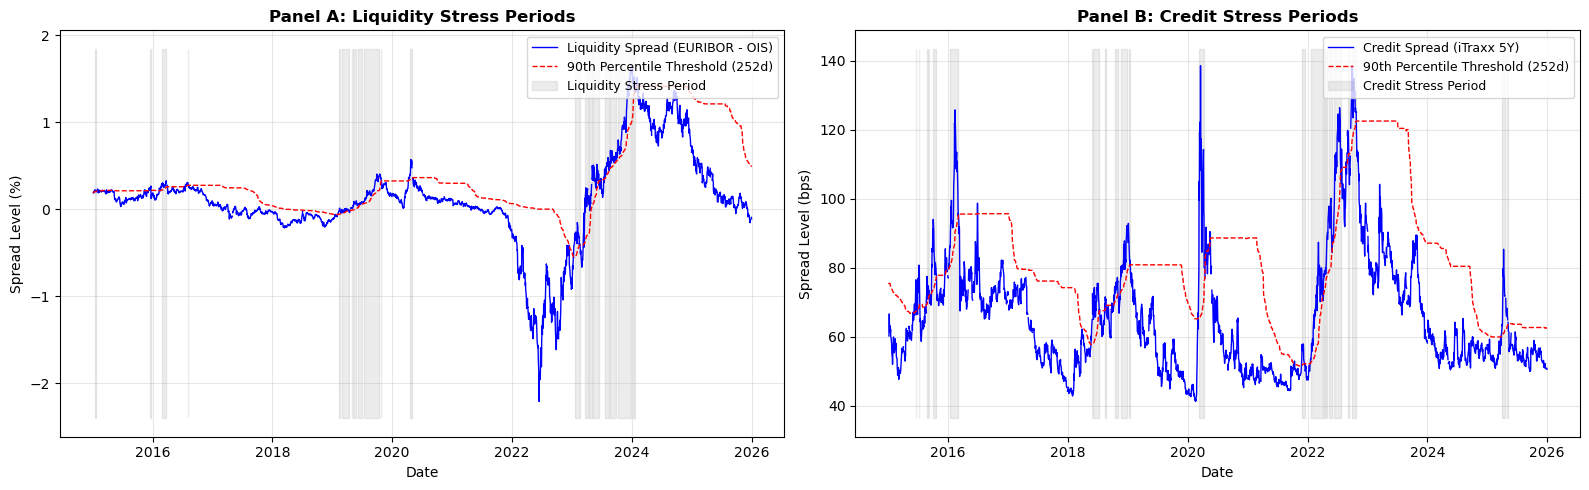

In [27]:
# Create double graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharex=False)

plot_start = '2015-01-01'
plot_end = '2025-12-31'

# Liquidity stress
# -------------------------------------------------------------------------
# Collect the data
liq_spread_series = raw_liquidity_spread.loc[plot_start:plot_end]
liq_threshold_series = rolling_liquidity_threshold.loc[plot_start:plot_end]
liq_stress_dummy = liquidity_stress_5d.loc[plot_start:plot_end]

# Plot the data
ax1.plot(liq_spread_series.index, liq_spread_series, label='Liquidity Spread (EURIBOR - OIS)', color='blue', linewidth=1)
ax1.plot(liq_threshold_series.index, liq_threshold_series, label='90th Percentile Threshold (252d)', color='red', linestyle='--', linewidth=1)

# Shade the background
ax1.fill_between(liq_spread_series.index, ax1.get_ylim()[0], ax1.get_ylim()[1], 
                 where=(liq_stress_dummy == 1), color='gray', alpha=0.15, label='Liquidity Stress Period')

ax1.set_title('Panel A: Liquidity Stress Periods', fontsize=12, fontweight='bold')
ax1.set_ylabel('Spread Level (%)')
ax1.set_xlabel('Date')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Credit stress
# -------------------------------------------------------------------------
# Collect the data
cred_spread_series = raw_credit_spread.loc[plot_start:plot_end]
cred_threshold_series = rolling_credit_threshold.loc[plot_start:plot_end]
cred_stress_dummy = credit_stress_5d.loc[plot_start:plot_end]

# Plot the data
ax2.plot(cred_spread_series.index, cred_spread_series, label='Credit Spread (iTraxx 5Y)', color='blue', linewidth=1)
ax2.plot(cred_threshold_series.index, cred_threshold_series, label='90th Percentile Threshold (252d)', color='red', linestyle='--', linewidth=1)

# Shade the background
ax2.fill_between(cred_spread_series.index, ax2.get_ylim()[0], ax2.get_ylim()[1], 
                 where=(cred_stress_dummy == 1), color='gray', alpha=0.15, label='Credit Stress Period')

ax2.set_title('Panel B: Credit Stress Periods', fontsize=12, fontweight='bold')
ax2.set_ylabel('Spread Level (bps)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot
plt.tight_layout()
plt.savefig("Stress_Periods_NBER_Style.png", dpi=300)
plt.show()

### Robustness tests

#### Robustness Test 1: Time-Series OLS on the Aggregated Daily Mean Difference

In [28]:
# Create a daily time-series DataFrame
# 'paired_df' already contains the daily mean difference: 'Difference' = NBFI_to_Bank - Bank_to_NBFI
df_ts = paired_df[['Difference']].copy()

# Map the stress dummies
df_ts['Liquidity_Stress'] = liquidity_stress_5d
df_ts['Credit_Stress'] = credit_stress_5d

# Join the lagged macro-financial control variables
macro_cols = ['V2X_Level', 'Liquidity_Spread', 'Term_Spread', 'Credit_Spread', 'Market_Return']
df_ts = df_ts.join(df_macro_panel[macro_cols])

# Drop any missing values
df_ts = df_ts.loc['2015-01-01':].dropna()

# Standardize the continuous macro variables (z-score) to put them on the same scale.
# This prevents the "large condition number" warning without affecting p-values/significance.
for col in macro_cols:
    df_ts[col] = (df_ts[col] - df_ts[col].mean()) / df_ts[col].std()

# Define dependent variable (Y)
Y_ts = df_ts['Difference']

# Liquidity Stress
# ----------------------------------------------------------------------------------
# We INCLUDE the Liquidity_Stress dummy but exclude the continuous Liquidity_Spread 
# to avoid mechanical overlap. Credit_Stress is also excluded here to match the 
# baseline methodology.
X_liq_ts = df_ts[['Liquidity_Stress', 'V2X_Level', 'Term_Spread', 'Credit_Spread', 'Market_Return']]

# Add a constant (alpha)
X_liq_ts = sm.add_constant(X_liq_ts)

# Fit the Time-Series OLS model using HAC (Newey-West) standard errors
ts_model_liq = sm.OLS(Y_ts, X_liq_ts)
ts_results_liq = ts_model_liq.fit(cov_type='HAC', cov_kwds={'maxlags': 5})

print("Robustness Check: Time-Series Regression (d_t) - Liquidity Stress Specification")
print(ts_results_liq.summary())

# Credit Stress
# ----------------------------------------------------------------------------------
# We INCLUDE the Credit_Stress dummy but exclude the continuous Credit_Spread 
# to avoid mechanical overlap. Liquidity_Stress is also excluded here.
X_cred_ts = df_ts[['Credit_Stress', 'V2X_Level', 'Liquidity_Spread', 'Term_Spread', 'Market_Return']]

# Add a constant (alpha)
X_cred_ts = sm.add_constant(X_cred_ts)

# Fit the Time-Series OLS model using HAC (Newey-West) standard errors
ts_model_cred = sm.OLS(Y_ts, X_cred_ts)
ts_results_cred = ts_model_cred.fit(cov_type='HAC', cov_kwds={'maxlags': 5})

print("\n\nRobustness Check: Time-Series Regression (d_t) - Credit Stress Specification")
print(ts_results_cred.summary())

Robustness Check: Time-Series Regression (d_t) - Liquidity Stress Specification
                            OLS Regression Results                            
Dep. Variable:             Difference   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     7.720
Date:                Mån, 14 Sep 2026   Prob (F-statistic):           3.23e-07
Time:                        00:23:45   Log-Likelihood:                 221.59
No. Observations:                2575   AIC:                            -431.2
Df Residuals:                    2569   BIC:                            -396.1
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

#### Robustness test 2: Stress-period definitions


In [29]:
# Create a clean base panel for the robustness checks to avoid overwriting the original
panel_bank_rob = dcc_results_df[dcc_results_df['Direction'] == 'Bank_to_NBFI'].copy()
panel_nbfi_rob = dcc_results_df[dcc_results_df['Direction'] == 'NBFI_to_Bank'].copy()

panel_robust_base = pd.concat([panel_bank_rob, panel_nbfi_rob])
panel_robust_base = panel_robust_base.set_index(['Entity', 'Date']).sort_index()
panel_robust_base = panel_robust_base.join(df_macro_panel)
panel_robust_base['Direction_Dummy'] = (panel_robust_base['Direction'] == 'NBFI_to_Bank').astype(int)

# Define Stress Regimes
raw_credit_spread = df_macro['ITRX EUR  CDSI GEN 5Y Index'].shift(1)
raw_liquidity_spread = (df_macro['EUR003M Index'] - df_macro['OIS']).shift(1)

# Robustness Test 1: 95th Percentile and 5-day window
# ----------------------------------------------------------------------------------

# Calculate rolling thresholds based on 95th percentile
window_size = 252 
rolling_credit_thresh_95 = raw_credit_spread.rolling(window=window_size, min_periods=126).quantile(0.95)
rolling_liquidity_thresh_95 = raw_liquidity_spread.rolling(window=window_size, min_periods=126).quantile(0.95)

# Check which days are above the threshold
daily_credit_stress_95 = (raw_credit_spread >= rolling_credit_thresh_95).astype(int)
daily_liquidity_stress_95 = (raw_liquidity_spread >= rolling_liquidity_thresh_95).astype(int)

# Need 5 days in a row
credit_stress_5d_95 = (daily_credit_stress_95.rolling(window=5).sum() == 5).astype(int)
liquidity_stress_5d_95 = (daily_liquidity_stress_95.rolling(window=5).sum() == 5).astype(int)

# Map to a new temporary panel
panel_rob1 = panel_robust_base.copy()
panel_rob1['Credit_Stress'] = panel_rob1.index.get_level_values('Date').map(credit_stress_5d_95)
panel_rob1['Liquidity_Stress'] = panel_rob1.index.get_level_values('Date').map(liquidity_stress_5d_95)

# Create interaction terms
panel_rob1['Credit_Stress_x_Dir'] = panel_rob1['Credit_Stress'] * panel_rob1['Direction_Dummy']
panel_rob1['Liquidity_Stress_x_Dir'] = panel_rob1['Liquidity_Stress'] * panel_rob1['Direction_Dummy']

# Sort index to prevent UnsortedIndexError
panel_rob1 = panel_rob1.sort_index()

# Clean missing observations
panel_rob1 = panel_rob1.loc[pd.IndexSlice[:, '2015-01-01':], :].dropna(
    subset=['V2X_Level', 'Term_Spread', 'Credit_Spread', 'Market_Return', 'Credit_Stress', 'Liquidity_Stress', 'Liquidity_Spread']
)

# Run regressions for Test 1
Y_rob1 = panel_rob1['DeltaCoVaR']

# --- ADDED: Credit Stress Regression ---
X_credit_rob1 = panel_rob1[['Credit_Stress', 'Direction_Dummy', 'Credit_Stress_x_Dir', 
                            'V2X_Level', 'Liquidity_Spread', 'Term_Spread', 'Market_Return']]
X_credit_rob1 = sm.add_constant(X_credit_rob1)
model_credit_rob1 = PanelOLS(Y_rob1, X_credit_rob1, entity_effects=False)
res_credit_rob1 = model_credit_rob1.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

# --- Original: Liquidity Stress Regression ---
X_liq_rob1 = panel_rob1[['Liquidity_Stress', 'Direction_Dummy', 'Liquidity_Stress_x_Dir', 
                         'V2X_Level', 'Credit_Spread','Term_Spread', 'Market_Return']]
X_liq_rob1 = sm.add_constant(X_liq_rob1)
model_liq_rob1 = PanelOLS(Y_rob1, X_liq_rob1, entity_effects=False)
res_liq_rob1 = model_liq_rob1.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print("Robustness Test 1: 95th Percentile, 5 Consecutive Days")
print("\n Credit Stress Panel")
print(res_credit_rob1)
print("\n Liquidity Stress Panel")
print(res_liq_rob1)

# Robustness Test 2: 90th Percentile and 3-day window
# ----------------------------------------------------------------------------------

# Calculate rolling thresholds based on 90th percentile (same as your original)
rolling_credit_thresh_90 = raw_credit_spread.rolling(window=window_size, min_periods=126).quantile(0.90)
rolling_liquidity_thresh_90 = raw_liquidity_spread.rolling(window=window_size, min_periods=126).quantile(0.90)

daily_credit_stress_90 = (raw_credit_spread >= rolling_credit_thresh_90).astype(int)
daily_liquidity_stress_90 = (raw_liquidity_spread >= rolling_liquidity_thresh_90).astype(int)

# Need 3 days in a row (instead of 5)
credit_stress_3d_90 = (daily_credit_stress_90.rolling(window=3).sum() == 3).astype(int)
liquidity_stress_3d_90 = (daily_liquidity_stress_90.rolling(window=3).sum() == 3).astype(int)

# Map to a new temporary panel
panel_rob2 = panel_robust_base.copy()
panel_rob2['Credit_Stress'] = panel_rob2.index.get_level_values('Date').map(credit_stress_3d_90)
panel_rob2['Liquidity_Stress'] = panel_rob2.index.get_level_values('Date').map(liquidity_stress_3d_90)

# Create interaction terms
panel_rob2['Credit_Stress_x_Dir'] = panel_rob2['Credit_Stress'] * panel_rob2['Direction_Dummy']
panel_rob2['Liquidity_Stress_x_Dir'] = panel_rob2['Liquidity_Stress'] * panel_rob2['Direction_Dummy']

# Sort index to prevent UnsortedIndexError
panel_rob2 = panel_rob2.sort_index()

# Clean missing observations
panel_rob2 = panel_rob2.loc[pd.IndexSlice[:, '2015-01-01':], :].dropna(
    subset=['V2X_Level', 'Term_Spread', 'Credit_Spread', 'Market_Return', 'Credit_Stress', 'Liquidity_Stress', 'Liquidity_Spread']
)

# Run regressions for Test 2
Y_rob2 = panel_rob2['DeltaCoVaR']

# --- ADDED: Credit Stress Regression ---
X_credit_rob2 = panel_rob2[['Credit_Stress', 'Direction_Dummy', 'Credit_Stress_x_Dir', 
                            'V2X_Level', 'Liquidity_Spread', 'Term_Spread', 'Market_Return']]
X_credit_rob2 = sm.add_constant(X_credit_rob2)
model_credit_rob2 = PanelOLS(Y_rob2, X_credit_rob2, entity_effects=False)
res_credit_rob2 = model_credit_rob2.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

# --- Original: Liquidity Stress Regression ---
X_liq_rob2 = panel_rob2[['Liquidity_Stress', 'Direction_Dummy', 'Liquidity_Stress_x_Dir', 
                         'V2X_Level', 'Credit_Spread','Term_Spread', 'Market_Return']]
X_liq_rob2 = sm.add_constant(X_liq_rob2)
model_liq_rob2 = PanelOLS(Y_rob2, X_liq_rob2, entity_effects=False)
res_liq_rob2 = model_liq_rob2.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print("Robustness Test 2: 90th Percentile, 3 Consecutive Days")
print("\n Credit Stress Panel ")
print(res_credit_rob2)
print("\n Liquidity Stress Panel ")
print(res_liq_rob2)

Robustness Test 1: 95th Percentile, 5 Consecutive Days

 Credit Stress Panel
                          PanelOLS Estimation Summary                           
Dep. Variable:             DeltaCoVaR   R-squared:                        0.5841
Estimator:                   PanelOLS   R-squared (Between):              0.1349
No. Observations:              170993   R-squared (Within):               0.6177
Date:                Mån, Sep 14 2026   R-squared (Overall):              0.5841
Time:                        00:23:45   Log-likelihood                -1.548e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   3.431e+04
Entities:                          75   P-value                           0.0000
Avg Obs:                       2279.9   Distribution:                F(7,170985)
Min Obs:                       61.000                                           
Max Obs:                       2

#### Robustness test 3: Financial-services sector only


Estimate Bank to financial services index (SXFP) with DCC-GARCH

In [30]:
%%R -i df_final -i bank_tickers -o dcc_sxfp_df

# Load required packages for GARCH and DCC modeling
library(rugarch)
library(rmgarch)

# Specify the univariate GARCH(1,1) model with a Student-t distribution
uspec <- ugarchspec(variance.model = list(model = "gjrGARCH", garchOrder = c(1, 1)),
                    mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
                    distribution.model = "std") 

# Replicate the univariate specification for the bivariate setup
multispec <- multispec(replicate(2, uspec))

# Specify the DCC model with a multivariate Student-t distribution (mvt)
dcc_spec <- dccspec(uspec = multispec, dccOrder = c(1, 1), distribution = "mvt")

# Initialize an empty list to store the results
results_sxfp <- list()

# Loop through each bank to estimate the bivariate model against the SXFP Index (Financial Services)
for(ticker in bank_tickers) {
  
  # Extract the pair of returns (Bank and SXFP), drop NAs, and scale by 100 
  # to help the optimization algorithm converge
  data_pair <- na.omit(df_final[, c(ticker, "SXFP Index")]) * 100
  
  # Fit the DCC-GARCH model. 
  # eval.se = FALSE speeds up estimation by skipping standard error calculations.
  fit_result <- dccfit(dcc_spec, data = data_pair, solver = "solnp", fit.control = list(eval.se = FALSE))
  
  all_coefs <- coef(fit_result)                    

  # Extract dynamic conditional correlation (rho), volatilities (sigma) and mean (mu)
  # as.numeric() is critical here to strip away internal R names
  results_sxfp[[paste0(ticker, "_to_SXFP")]] <- data.frame(
    Date = as.character(rownames(data_pair)),
    Entity = ticker,
    Index_Name = "SXFP Index",
    Direction = "Bank_to_FinServices",
    Correlation = as.numeric(rcor(fit_result)[1, 2, ]),
    Vol_Entity = as.numeric(sigma(fit_result)[, 1]), # Bank
    Vol_Index = as.numeric(sigma(fit_result)[, 2]),  # SXFP Index
    Mean_Entity = as.numeric(fitted(fit_result)[, 1]),
    Mean_Index = as.numeric(fitted(fit_result)[, 2]),
    Shape_Entity = as.numeric(all_coefs[paste0("[", ticker, "].shape")]),
    Shape_Index = as.numeric(all_coefs["[SXFP Index].shape"])
  )
}

# Combine everything into a single dataframe
dcc_sxfp_df <- do.call(rbind, results_sxfp)

# Remove row names for a cleaner dataframe structure
rownames(dcc_sxfp_df) <- NULL

Fix the data and do the tests

In [31]:
# Clean the new dataframe from R
dcc_sxfp_df['Date'] = pd.to_datetime(dcc_sxfp_df['Date'])
mask = (dcc_sxfp_df['Date'] >= '2015-01-01') & (dcc_sxfp_df['Date'] <= '2025-12-31')
dcc_sxfp_df = dcc_sxfp_df[mask].reset_index(drop=True)

# Calculate DeltaCoVaR for Bank -> FinServices (SXFP)
alpha = 0.05
nu = dcc_sxfp_df['Shape_Entity']
t_score = t.ppf(alpha, df=nu) * np.sqrt((nu - 2) / nu)

dcc_sxfp_df['VaR_Entity'] = (dcc_sxfp_df['Mean_Entity'] + t_score * dcc_sxfp_df['Vol_Entity']) * -1
dcc_sxfp_df['VaR_Median_Entity'] = (dcc_sxfp_df['Mean_Entity']) * -1
dcc_sxfp_df['Beta'] = dcc_sxfp_df['Correlation'] * (dcc_sxfp_df['Vol_Index'] / dcc_sxfp_df['Vol_Entity'])
dcc_sxfp_df['DeltaCoVaR'] = dcc_sxfp_df['Beta'] * (dcc_sxfp_df['VaR_Entity'] - dcc_sxfp_df['VaR_Median_Entity'])

# Calculate daily means for Bank -> FinServices
mean_b2f = dcc_sxfp_df.groupby('Date')['DeltaCoVaR'].mean()

# Extract FinServices -> Bank from your original results
# Using the updated df_sectors to find only Financial Services firms
fin_services_tickers = df_sectors[df_sectors['Type'] == 'Financial Services']['Ticker'].tolist()
mask_fin_services = (dcc_results_df['Direction'] == 'NBFI_to_Bank') & (dcc_results_df['Entity'].isin(fin_services_tickers))
mean_f2b = dcc_results_df[mask_fin_services].groupby('Date')['DeltaCoVaR'].mean()

# Pair up observations
paired_perfect_df = pd.DataFrame({
    'Bank_to_FinServices': mean_b2f,
    'FinServices_to_Bank': mean_f2b
}).dropna()

# Difference is now a perfectly symmetrical comparison
paired_perfect_df['Difference'] = paired_perfect_df['FinServices_to_Bank'] - paired_perfect_df['Bank_to_FinServices']

# Statistical tests
stat_w_perf, p_w_perf = stats.wilcoxon(paired_perfect_df['Difference'])
stat_t_perf, p_t_perf = stats.ttest_rel(paired_perfect_df['FinServices_to_Bank'], paired_perfect_df['Bank_to_FinServices'])

mod_perf = smf.ols('Difference ~ 1', data=paired_perfect_df)
res_nw_perf = mod_perf.fit(cov_type='HAC', cov_kwds={'maxlags': 5})
t_stat_nw_perf = res_nw_perf.tvalues['Intercept']
p_val_nw_perf = res_nw_perf.pvalues['Intercept']

# Print results
print(f"Wilcoxon test: stat={stat_w_perf:.4f}, p-val={p_w_perf:.4e}")
print(f"Paired t-test: stat={stat_t_perf:.4f}, p-val={p_t_perf:.4e}")
print(f"Newey-West t-test: stat={t_stat_nw_perf:.4f}, p-val={p_val_nw_perf:.4e}\n")

print("Overall Means:")
print(f"Bank -> Financial Services (SXFP): {paired_perfect_df['Bank_to_FinServices'].mean():.6f}")
print(f"Financial Services -> Bank (SX7P): {paired_perfect_df['FinServices_to_Bank'].mean():.6f}")

print("\nOverall Medians:")
print(f"Bank -> Financial Services (SXFP): {paired_perfect_df['Bank_to_FinServices'].median():.6f}")
print(f"Financial Services -> Bank (SX7P): {paired_perfect_df['FinServices_to_Bank'].median():.6f}")
print(f"Median of the daily differences:   {paired_perfect_df['Difference'].median():.6f}")

Wilcoxon test: stat=1122776.0000, p-val=4.8965e-89
Paired t-test: stat=20.9786, p-val=6.4671e-91
Newey-West t-test: stat=9.0037, p-val=2.1816e-19

Overall Means:
Bank -> Financial Services (SXFP): 1.018695
Financial Services -> Bank (SX7P): 1.131606

Overall Medians:
Bank -> Financial Services (SXFP): 0.814481
Financial Services -> Bank (SX7P): 0.892682
Median of the daily differences:   0.061046


In [32]:
# Panel regressions

# Create a panel for Bank -> FinServices (using your new dcc_sxfp_df)
panel_b2f = dcc_sxfp_df.copy()
panel_b2f = panel_b2f.set_index(['Entity', 'Date']).sort_index()

# Extract FinServices -> Bank from original panel
fin_services_tickers = df_sectors[df_sectors['Type'] == 'Financial Services']['Ticker'].tolist()
mask_f2b = (dcc_results_df['Direction'] == 'NBFI_to_Bank') & (dcc_results_df['Entity'].isin(fin_services_tickers))
panel_f2b = dcc_results_df[mask_f2b].copy()
panel_f2b = panel_f2b.set_index(['Entity', 'Date']).sort_index()

# Combine and join with macro data
panel_bfs = pd.concat([panel_b2f, panel_f2b])
panel_bfs = panel_bfs.join(df_macro_panel)

# Direction dummy: 1 if FinServices -> Bank, 0 if Bank -> FinServices
panel_bfs['Direction_Dummy'] = (panel_bfs['Direction'] == 'NBFI_to_Bank').astype(int)

# Map ALL stress periods (using your original 5-day baseline rules)
panel_bfs['Credit_Stress'] = panel_bfs.index.get_level_values('Date').map(credit_stress_5d)
panel_bfs['Liquidity_Stress'] = panel_bfs.index.get_level_values('Date').map(liquidity_stress_5d)

# Create interaction terms
panel_bfs['Credit_Stress_x_Dir'] = panel_bfs['Credit_Stress'] * panel_bfs['Direction_Dummy']
panel_bfs['Liquidity_Stress_x_Dir'] = panel_bfs['Liquidity_Stress'] * panel_bfs['Direction_Dummy']

# Sort the index
panel_bfs = panel_bfs.sort_index()

# Clean missing observations for the stress panels
panel_bfs_stress = panel_bfs.loc[pd.IndexSlice[:, '2015-01-01':], :].dropna(
    subset=['V2X_Level', 'Term_Spread', 'Credit_Spread', 'Market_Return', 'Credit_Stress', 'Liquidity_Stress', 'Liquidity_Spread']
)

# Credit stress
# -------------------------------------------------------------------------------
Y_bfs_stress = panel_bfs_stress['DeltaCoVaR']

X_credit_bfs = panel_bfs_stress[['Credit_Stress', 'Direction_Dummy', 'Credit_Stress_x_Dir', 
                                   'V2X_Level', 'Liquidity_Spread', 'Term_Spread', 'Market_Return']]
X_credit_bfs = sm.add_constant(X_credit_bfs)

model_credit_bfs = PanelOLS(Y_bfs_stress, X_credit_bfs, entity_effects=False)
res_credit_bfs = model_credit_bfs.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

# Liquidity stress
# -------------------------------------------------------------------------------
X_liq_bfs = panel_bfs_stress[['Liquidity_Stress', 'Direction_Dummy', 'Liquidity_Stress_x_Dir', 
                                'V2X_Level', 'Credit_Spread','Term_Spread', 'Market_Return']]
X_liq_bfs = sm.add_constant(X_liq_bfs)

model_liq_bfs = PanelOLS(Y_bfs_stress, X_liq_bfs, entity_effects=False)
res_liq_bfs = model_liq_bfs.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

# Sub-question 2
# -------------------------------------------------------------------------------
# Clean data specifically for the Sub-question 2 model
X_combined_bfs = panel_bfs[['Direction_Dummy', 'V2X_Level', 'Liquidity_Spread', 
                              'Term_Spread', 'Credit_Spread', 'Market_Return']].dropna()
Y_combined_bfs = panel_bfs['DeltaCoVaR'].loc[X_combined_bfs.index]

X_combined_bfs = sm.add_constant(X_combined_bfs)

# Using PooledOLS exactly as you did in your main code for Hyp 2
model_hyp2_bfs = PooledOLS(Y_combined_bfs, X_combined_bfs)
res_hyp2_bfs = model_hyp2_bfs.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

# Print
print("Credit stress")
print(res_credit_bfs)

print("Liquidity stress")
print(res_liq_bfs)

print("Sub-question 2")
print(res_hyp2_bfs)

Credit stress
                          PanelOLS Estimation Summary                           
Dep. Variable:             DeltaCoVaR   R-squared:                        0.5666
Estimator:                   PanelOLS   R-squared (Between):              0.2639
No. Observations:              114354   R-squared (Within):               0.5962
Date:                Mån, Sep 14 2026   R-squared (Overall):              0.5666
Time:                        00:24:15   Log-likelihood                -9.686e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   2.135e+04
Entities:                          50   P-value                           0.0000
Avg Obs:                       2287.1   Distribution:                F(7,114346)
Min Obs:                       446.00                                           
Max Obs:                       2567.0   F-statistic (robust):             140.69
              

#### Robustness test 4: Tail risk definition 1% VaR

In [33]:
# Create a copy of the original DCC results to preserve the baseline data
dcc_results_1pct = dcc_results_df.copy()

# Recalculate VaR and DeltaCoVaR for the 1% tail level
alpha_1pct = 0.01

# Recalculate the t-score for the 1% level
nu_1pct = dcc_results_1pct['Shape_Entity']
t_score_1pct = t.ppf(alpha_1pct, df=nu_1pct) * np.sqrt((nu_1pct - 2) / nu_1pct)

# Calculate the new 1% VaR
dcc_results_1pct['VaR_Entity_1pct'] = (dcc_results_1pct['Mean_Entity'] + t_score_1pct * dcc_results_1pct['Vol_Entity']) * -1

# The median state remains the same (50th percentile)
dcc_results_1pct['VaR_Median_Entity'] = (dcc_results_1pct['Mean_Entity']) * -1

# Calculate dynamic Beta (spillover) - this is structurally the same
dcc_results_1pct['Beta'] = dcc_results_1pct['Correlation'] * (dcc_results_1pct['Vol_Index'] / dcc_results_1pct['Vol_Entity'])

# Calculate the new DeltaCoVaR at the 1% level
dcc_results_1pct['DeltaCoVaR_1pct'] = dcc_results_1pct['Beta'] * (dcc_results_1pct['VaR_Entity_1pct'] - dcc_results_1pct['VaR_Median_Entity'])

# Directional Asymmetry test 
# -------------------------------------------------------------------------------
# Calculate daily cross-sectional means for both directions
mean_b2n_1pct = dcc_results_1pct[dcc_results_1pct['Direction'] == 'Bank_to_NBFI'].groupby('Date')['DeltaCoVaR_1pct'].mean()
mean_n2b_1pct = dcc_results_1pct[dcc_results_1pct['Direction'] == 'NBFI_to_Bank'].groupby('Date')['DeltaCoVaR_1pct'].mean()

# Pair observations by date
paired_df_1pct = pd.DataFrame({
    'Bank_to_NBFI': mean_b2n_1pct,
    'NBFI_to_Bank': mean_n2b_1pct
}).dropna()

# Calculate daily differences
paired_df_1pct['Difference'] = paired_df_1pct['NBFI_to_Bank'] - paired_df_1pct['Bank_to_NBFI']

# Statistical tests
stat_w_1pct, p_w_1pct = stats.wilcoxon(paired_df_1pct['Difference'])
stat_t_1pct, p_t_1pct = stats.ttest_rel(paired_df_1pct['NBFI_to_Bank'], paired_df_1pct['Bank_to_NBFI'])

mod_1pct = smf.ols('Difference ~ 1', data=paired_df_1pct)
res_nw_1pct = mod_1pct.fit(cov_type='HAC', cov_kwds={'maxlags': 5})
t_stat_nw_1pct = res_nw_1pct.tvalues['Intercept']
p_val_nw_1pct = res_nw_1pct.pvalues['Intercept']

print("Robustness test 4: Tail risk definition 1% VaR")
print("\n Directional Asymmetry Test (1% Level) ")
print(f"Wilcoxon test: stat={stat_w_1pct:.4f}, p-val={p_w_1pct:.4e}")
print(f"Paired t-test: stat={stat_t_1pct:.4f}, p-val={p_t_1pct:.4e}")
print(f"Newey-West t-test: stat={t_stat_nw_1pct:.4f}, p-val={p_val_nw_1pct:.4e}\n")

print("Overall Means (Delta CoVaR 1%):")
print(f"Bank -> NBFI: {paired_df_1pct['Bank_to_NBFI'].mean():.6f}")
print(f"NBFI -> Bank: {paired_df_1pct['NBFI_to_Bank'].mean():.6f}")

print("\nOverall Medians (Delta CoVaR 1%):")
print(f"Bank -> NBFI: {paired_df_1pct['Bank_to_NBFI'].median():.6f}")
print(f"NBFI -> Bank: {paired_df_1pct['NBFI_to_Bank'].median():.6f}")
print(f"Median of the daily differences: {paired_df_1pct['Difference'].median():.6f}")


# Panel regressions
# -------------------------------------------------------------------------------

# Setup the panel data for 1% DeltaCoVaR
panel_b2n_1pct = dcc_results_1pct[dcc_results_1pct['Direction'] == 'Bank_to_NBFI'].copy()
panel_n2b_1pct = dcc_results_1pct[dcc_results_1pct['Direction'] == 'NBFI_to_Bank'].copy()

panel_comb_1pct = pd.concat([panel_b2n_1pct, panel_n2b_1pct])
panel_comb_1pct = panel_comb_1pct.set_index(['Entity', 'Date']).sort_index()

# Merge with macro variables
panel_comb_1pct = panel_comb_1pct.join(df_macro_panel)
panel_comb_1pct['Direction_Dummy'] = (panel_comb_1pct['Direction'] == 'NBFI_to_Bank').astype(int)

# Map stress periods (using your baseline 5-day rule)
panel_comb_1pct['Credit_Stress'] = panel_comb_1pct.index.get_level_values('Date').map(credit_stress_5d)
panel_comb_1pct['Liquidity_Stress'] = panel_comb_1pct.index.get_level_values('Date').map(liquidity_stress_5d)

panel_comb_1pct['Credit_Stress_x_Dir'] = panel_comb_1pct['Credit_Stress'] * panel_comb_1pct['Direction_Dummy']
panel_comb_1pct['Liquidity_Stress_x_Dir'] = panel_comb_1pct['Liquidity_Stress'] * panel_comb_1pct['Direction_Dummy']

# Clean missing observations
panel_comb_1pct = panel_comb_1pct.loc[pd.IndexSlice[:, '2015-01-01':], :].dropna(
    subset=['V2X_Level', 'Term_Spread', 'Credit_Spread', 'Market_Return', 'Credit_Stress', 'Liquidity_Stress', 'Liquidity_Spread']
)

Y_1pct = panel_comb_1pct['DeltaCoVaR_1pct']

# Credit stress
X_credit_1pct = panel_comb_1pct[['Credit_Stress', 'Direction_Dummy', 'Credit_Stress_x_Dir', 
                                 'V2X_Level', 'Liquidity_Spread', 'Term_Spread', 'Market_Return']]
X_credit_1pct = sm.add_constant(X_credit_1pct)
model_credit_1pct = PanelOLS(Y_1pct, X_credit_1pct, entity_effects=False)
res_credit_1pct = model_credit_1pct.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

# Liquidity Stress (1%)
X_liq_1pct = panel_comb_1pct[['Liquidity_Stress', 'Direction_Dummy', 'Liquidity_Stress_x_Dir', 
                              'V2X_Level', 'Credit_Spread','Term_Spread', 'Market_Return']]
X_liq_1pct = sm.add_constant(X_liq_1pct)
model_liq_1pct = PanelOLS(Y_1pct, X_liq_1pct, entity_effects=False)
res_liq_1pct = model_liq_1pct.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

# Sub question 2
X_macro_1pct = panel_comb_1pct[['Direction_Dummy', 'V2X_Level', 'Liquidity_Spread', 
                                'Term_Spread', 'Credit_Spread', 'Market_Return']].dropna()
Y_macro_1pct = panel_comb_1pct['DeltaCoVaR_1pct'].loc[X_macro_1pct.index]
X_macro_1pct = sm.add_constant(X_macro_1pct)

model_macro_1pct = PooledOLS(Y_macro_1pct, X_macro_1pct)
res_macro_1pct = model_macro_1pct.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print("\n\n 1% VaR: Credit Stress Asymmetry ")
print(res_credit_1pct)

print("\n\n 1% VaR: Liquidity Stress Asymmetry ")
print(res_liq_1pct)

print("\n\n 1% VaR: Macro Controls (Hypothesis 2) ")
print(res_macro_1pct)

Robustness test 4: Tail risk definition 1% VaR

 Directional Asymmetry Test (1% Level) 
Wilcoxon test: stat=410170.0000, p-val=1.9783e-292
Paired t-test: stat=37.0021, p-val=1.1031e-244
Newey-West t-test: stat=16.1836, p-val=6.5828e-59

Overall Means (Delta CoVaR 1%):
Bank -> NBFI: 1.820036
NBFI -> Bank: 2.089846

Overall Medians (Delta CoVaR 1%):
Bank -> NBFI: 1.432795
NBFI -> Bank: 1.675129
Median of the daily differences: 0.216705


 1% VaR: Credit Stress Asymmetry 
                          PanelOLS Estimation Summary                           
Dep. Variable:        DeltaCoVaR_1pct   R-squared:                        0.5873
Estimator:                   PanelOLS   R-squared (Between):              0.1665
No. Observations:              170993   R-squared (Within):               0.6177
Date:                Mån, Sep 14 2026   R-squared (Overall):              0.5873
Time:                        00:24:17   Log-likelihood                -2.434e+05
Cov. Estimator:             Clustered   